In [1171]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, confusion_matrix, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

In [1172]:
tdata = pd.read_csv("ames_train.csv")
tdata.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [1173]:
print(tdata.shape)

(1460, 81)


In [1174]:
tdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [1175]:
tdata.isnull().sum()[tdata.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [1176]:
tdata = tdata.drop(["LotFrontage","Alley","MasVnrType", "PoolQC","Fence","MiscFeature"], axis = 1)
tdata.shape

(1460, 75)

In [1177]:
tdata.isnull().sum()[tdata.isnull().sum() > 0]

MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
FireplaceQu     690
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

In [1178]:
tdata["FireplaceQu"].value_counts()
#Fire Place condition
      
       #Ex	Excellent - Exceptional Masonry Fireplace
       #Gd	Good - Masonry Fireplace in main level
       #TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       #Fa	Fair - Prefabricated Fireplace in basement
       #Po	Poor - Ben Franklin Stove
       #NA	No Fireplace

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

In [1179]:
tdata["FireplaceQu"] = tdata["FireplaceQu"].fillna("No")

map_fire_quality = {
    "Ex" : 6,
    "Gd" : 5,
    "TA" : 4,
    "Fa" : 3,
    "Po" : 2,
    "No" : 1
}
tdata["FireplaceQu"] = tdata["FireplaceQu"].map(map_fire_quality)
tdata["FireplaceQu"].value_counts()

FireplaceQu
1    690
5    380
4    313
3     33
6     24
2     20
Name: count, dtype: int64

In [1180]:
tdata["GarageType"].value_counts
       
       #2Types	More than one type of garage
       #Attchd	Attached to home
       #Basment	Basement Garage
       #BuiltIn	Built-In (Garage part of house - typically has room above garage)
       #CarPort	Car Port
       #Detchd	Detached from home
       #NA	No Garage

<bound method IndexOpsMixin.value_counts of 0       Attchd
1       Attchd
2       Attchd
3       Detchd
4       Attchd
         ...  
1455    Attchd
1456    Attchd
1457    Attchd
1458    Attchd
1459    Attchd
Name: GarageType, Length: 1460, dtype: object>

In [1181]:
tdata["GarageType"] = tdata["GarageType"].fillna("No")
tdata["GarageType"].value_counts()

GarageType
Attchd     870
Detchd     387
BuiltIn     88
No          81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

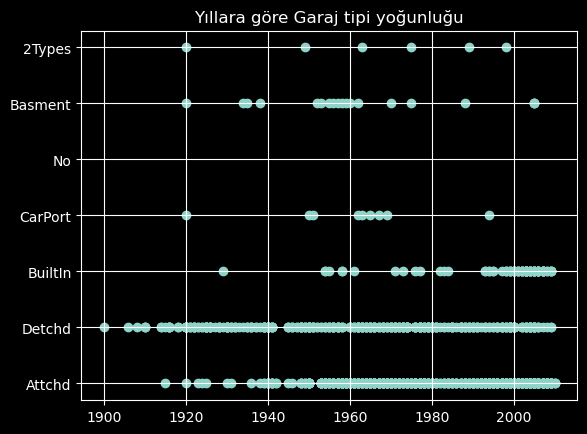

In [1182]:
plt.style.use("dark_background")
#print(tdata["GarageYrBlt"].agg(["median", "mean"]))
plt.scatter(tdata["GarageYrBlt"], tdata["GarageType"])
plt.title("Yıllara göre Garaj tipi yoğunluğu")
plt.grid(True)

In [1183]:
tdata["GarageYrBlt"] = tdata["GarageYrBlt"].fillna(np.nanmedian(tdata["GarageYrBlt"]))
tdata["GarageYrBlt"].isnull().sum()
#I used media to fill NaN's.

np.int64(0)

In [1184]:
tdata["GarageFinish"].value_counts
       #Fin	Finished
       #RFn	Rough Finished	
       #Unf	Unfinished
       #NA	No Garage

<bound method IndexOpsMixin.value_counts of 0       RFn
1       RFn
2       RFn
3       Unf
4       RFn
       ... 
1455    RFn
1456    Unf
1457    RFn
1458    Unf
1459    Fin
Name: GarageFinish, Length: 1460, dtype: object>

In [1185]:
tdata["GarageFinish"] = tdata["GarageFinish"].fillna("No")
tdata["GarageFinish"].value_counts()

GarageFinish
Unf    605
RFn    422
Fin    352
No      81
Name: count, dtype: int64

In [1186]:
tdata["GarageQual"].value_counts()

       #Ex	Excellent
       #Gd	Good
       #TA	Typical/Average
       #Fa	Fair
       #Po	Poor
       #NA	No Garage

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

In [1187]:
tdata["GarageQual"] = tdata["GarageQual"].fillna("No")
map_garage_quality = {
    "Ex" : 6,
    "Gd" : 5,
    "TA" : 4,
    "Fa" : 3,
    "Po" : 2,
    "No" : 1
}
tdata["GarageQual"] = tdata["GarageQual"].map(map_garage_quality)
tdata["GarageQual"].value_counts()

GarageQual
4    1311
1      81
3      48
5      14
6       3
2       3
Name: count, dtype: int64

In [1188]:
tdata["GarageCond"] = tdata["GarageCond"].fillna("No")
map_garage_quality = {
    "Ex" : 6,
    "Gd" : 5,
    "TA" : 4,
    "Fa" : 3,
    "Po" : 2,
    "No" : 1
}
tdata["GarageCond"] = tdata["GarageCond"].map(map_garage_quality)
tdata["GarageCond"].value_counts()

GarageCond
4    1326
1      81
3      35
5       9
2       7
6       2
Name: count, dtype: int64

In [1189]:
tdata["Electrical"] = tdata["Electrical"].fillna("SBrkr")
tdata["Electrical"].value_counts()

Electrical
SBrkr    1335
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [1190]:
tdata["BsmtFinType2"].value_counts()

       #GLQ	Good Living Quarters
       #ALQ	Average Living Quarters#Ω
       #BLQ	Below Average Living Quarters	
       #Rec	Average Rec Room
       #LwQ	Low Quality
       #Unf	Unfinshed
       #NA	No Basement

BsmtFinType2
Unf    1256
Rec      54
LwQ      46
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64

In [1191]:
tdata["BsmtFinType2"] = tdata["BsmtFinType2"].fillna("No")
map_basementtype_quality = {
    "Unf" : 2,
    "Rec" : 4,
    "LwQ" : 3,
    "BLQ" : 5,
    "ALQ" : 6,
    "GLQ" : 7,
    "No" : 1
}
tdata["BsmtFinType2"] = tdata["BsmtFinType2"].map(map_basementtype_quality)
tdata["BsmtFinType2"].value_counts()

BsmtFinType2
2    1256
4      54
3      46
1      38
5      33
6      19
7      14
Name: count, dtype: int64

In [1192]:
tdata["BsmtFinType1"].value_counts()

BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
Name: count, dtype: int64

In [1193]:
tdata["BsmtFinType1"] = tdata["BsmtFinType1"].fillna("No")
map_basementtype_quality = {
    "Unf" : 2,
    "Rec" : 4,
    "LwQ" : 3,
    "BLQ" : 5,
    "ALQ" : 6,
    "GLQ" : 7,
    "No" : 1
}
tdata["BsmtFinType1"] = tdata["BsmtFinType1"].map(map_basementtype_quality)
tdata["BsmtFinType1"].value_counts()

BsmtFinType1
2    430
7    418
6    220
5    148
4    133
3     74
1     37
Name: count, dtype: int64

In [1194]:
tdata["BsmtExposure"].value_counts()

       #Gd	Good Exposure
       #Av	Average Exposure (split levels or foyers typically score average or above)	
       #Mn	Mimimum Exposure
       #No	No Exposure
       #NA	No Basement

BsmtExposure
No    953
Av    221
Gd    134
Mn    114
Name: count, dtype: int64

In [1195]:
tdata["BsmtExposure"] = tdata["BsmtExposure"].fillna("Na")
map_basementtype_exposure = {
    "Gd" : 5,
    "Av" : 4,
    "Mn" : 3,
    "No" : 2,
    "Na" : 1
}
tdata["BsmtExposure"] = tdata["BsmtExposure"].map(map_basementtype_exposure)
tdata["BsmtExposure"].value_counts()

BsmtExposure
2    953
4    221
5    134
3    114
1     38
Name: count, dtype: int64

In [1196]:
tdata["BsmtCond"].value_counts()

BsmtCond
TA    1311
Gd      65
Fa      45
Po       2
Name: count, dtype: int64

In [1197]:
tdata["BsmtCond"] = tdata["BsmtCond"].fillna("No")
map_basementtype_exposure = {
    "Gd" : 5,
    "TA" : 4,
    "Fa" : 3,
    "Po" : 2,
    "No" : 1
}
tdata["BsmtCond"] = tdata["BsmtCond"].map(map_basementtype_exposure)
tdata["BsmtCond"].value_counts()

BsmtCond
4    1311
5      65
3      45
1      37
2       2
Name: count, dtype: int64

In [1198]:
tdata["BsmtQual"].value_counts()

BsmtQual
TA    649
Gd    618
Ex    121
Fa     35
Name: count, dtype: int64

In [1199]:
tdata["BsmtQual"] = tdata["BsmtQual"].fillna("No")
map_basementtype_exposure = {
    "Gd" : 4,
    "TA" : 3,
    "Fa" : 2,
    "Ex" : 5,
    "No" : 1
}
tdata["BsmtQual"] = tdata["BsmtQual"].map(map_basementtype_exposure)
tdata["BsmtQual"].value_counts()

BsmtQual
3    649
4    618
5    121
1     37
2     35
Name: count, dtype: int64

In [1200]:
tdata["MasVnrArea"].value_counts()
#Evin dış cephesindeki dekoratif taş/tuğla kaplamanın alanı (feet² cinsinden).

MasVnrArea
0.0      861
180.0      8
72.0       8
108.0      8
120.0      7
        ... 
562.0      1
89.0       1
921.0      1
762.0      1
119.0      1
Name: count, Length: 327, dtype: int64

In [1201]:
tdata["MasVnrArea"] = tdata["MasVnrArea"].fillna(np.nanmedian(tdata["MasVnrArea"]))
tdata["MasVnrArea"].isnull().sum()

np.int64(0)

In [1202]:
tdata.isnull().sum().unique()

array([0])

In [1203]:
tdata.select_dtypes(include="object").columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [1204]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#Aağaç tabnalı modellerde regresyon yaparken ordinal veya nominal ne olursa
#olsun max 25-30 farklı unique olmadığı sürece labelencoding kullanılabilir.
tdata["MSZoning"].value_counts()
#Konumlandığı bölge
tdata["MSZoning"] = le.fit_transform(tdata["MSZoning"])

In [1205]:
tdata["Street"].value_counts()
#Type of road access to property
tdata["Street"] = le.fit_transform(tdata["Street"])

In [1206]:
tdata["LotShape"].value_counts()
#General shape of property
tdata["LotShape"] = le.fit_transform(tdata["LotShape"])

In [1207]:
tdata["LandContour"] = tdata["LandContour"].fillna("No")
map_basementtype_exposure = {
    "Lvl" : 4,
    "Bnk" : 3,
    "HLS" : 2,
    "Low" : 1
}
tdata["LandContour"] = tdata["LandContour"].map(map_basementtype_exposure)
tdata["LandContour"].value_counts()

LandContour
4    1311
3      63
2      50
1      36
Name: count, dtype: int64

In [1208]:
tdata["Utilities"].value_counts()
#Type of utilities available --> altyapı hizmetleri
tdata["Utilities"] = le.fit_transform(tdata["Utilities"])

In [1209]:
tdata["LotConfig"].value_counts()
#Arsa konumu
tdata["LotConfig"] = le.fit_transform(tdata["LotConfig"])

In [1210]:
tdata["LandSlope"].value_counts()
#Slope of 
	
       #Gtl	Gentle slope
       #Mod	Moderate Slope	
       #Sev	Severe Slope

tdata["LandSlope"] = le.fit_transform(tdata["LandSlope"])

In [1211]:
tdata["Neighborhood"].value_counts()

tdata["Neighborhood"] = le.fit_transform(tdata["Neighborhood"])

In [1212]:
tdata["Condition1"].value_counts()
#Çevredekilere yakınlık(tren, okul...)
tdata["Condition1"] = le.fit_transform(tdata["Condition1"])

In [1213]:
tdata["Condition2"].value_counts()
#Çevredekilere yakınlık(tren, okul if more than one
tdata["Condition2"] = le.fit_transform(tdata["Condition2"])

In [1214]:
tdata["BldgType"].value_counts()
#Konut türü
tdata["BldgType"] = le.fit_transform(tdata["BldgType"])

In [1215]:
tdata["HouseStyle"].value_counts()
#Kat yapısı 1 katlı 3 katlı...
tdata["HouseStyle"] = le.fit_transform(tdata["HouseStyle"])

In [1216]:
tdata["RoofStyle"].value_counts()
#Çatı stili
tdata["RoofStyle"] = le.fit_transform(tdata["RoofStyle"])

In [1217]:
tdata["RoofMatl"].value_counts()
#Çatı yapım materyali
tdata["RoofMatl"] = le.fit_transform(tdata["RoofMatl"])

In [1218]:
tdata["Exterior1st"].value_counts()
#Ev dış malzeme
tdata["Exterior1st"] = le.fit_transform(tdata["Exterior1st"])

In [1219]:
tdata["Exterior2nd"].value_counts()
#Ev dış malzeme2
tdata["Exterior2nd"] = le.fit_transform(tdata["Exterior2nd"])

In [1220]:
tdata["ExterQual"].value_counts()
#Ev dış malzeme2
tdata["ExterQual"] = le.fit_transform(tdata["ExterQual"])

In [1221]:
tdata["ExterCond"].value_counts()
#Ev dış yenilik durumu
tdata["ExterCond"] = le.fit_transform(tdata["ExterCond"])

In [1222]:
tdata["Foundation"].value_counts()
#Yapım ana malzeme
tdata["Foundation"] = le.fit_transform(tdata["Foundation"])

In [1223]:
tdata["Heating"].value_counts()
#ısı türü
tdata["Heating"] = le.fit_transform(tdata["Heating"])

In [1224]:
tdata["HeatingQC"].value_counts()
#ısı kalite durumu
tdata["HeatingQC"] = le.fit_transform(tdata["HeatingQC"])

In [1225]:
tdata["CentralAir"] = tdata["CentralAir"].fillna("No")
map_basementtype_exposure = {
    "Y" : 2,
    "N" : 1,
    "No" : 0
}
tdata["CentralAir"] = tdata["CentralAir"].map(map_basementtype_exposure)
tdata["CentralAir"].value_counts()

CentralAir
2    1365
1      95
Name: count, dtype: int64

In [1226]:
tdata["Electrical"].value_counts()
#elektrik türü kalite

       #SBrkr	Standard Circuit Breakers & Romex(Good)
       #FuseA	Fuse Box over 60 AMP and all Romex wiring (Average)	
       #FuseF	60 AMP Fuse Box and mostly Romex wiring (Fair)
       #FuseP	60 AMP Fuse Box and mostly knob & tube wiring (poor)
       #Mix	Mixed

tdata["Electrical"] = le.fit_transform(tdata["Electrical"])

In [1227]:
tdata["KitchenQual"] = tdata["KitchenQual"].fillna("No")
map_basementtype_exposure = {
    "TA" : 3,
    "Gd" : 4,
    "Ex" : 5,
    "Fa" : 2,
    "No" : 1
}
tdata["KitchenQual"] = tdata["KitchenQual"].map(map_basementtype_exposure)
tdata["KitchenQual"].value_counts()

KitchenQual
3    735
4    586
5    100
2     39
Name: count, dtype: int64

#Functional: Home functionality (Assume typical unless deductions are warranted)

       Typ	Typical Functionality
       Min1	Minor Deductions 1
       Min2	Minor Deductions 2
       Mod	Moderate Deductions
       Maj1	Major Deductions 1
       Maj2	Major Deductions 2
       Sev	Severely Damaged
       Sal	Salvage only

In [1228]:
tdata["Functional"].value_counts()
tdata["Functional"] = le.fit_transform(tdata["Functional"])

In [1229]:
tdata["PavedDrive"].value_counts()
#sokaktan eve gelirken üzerinden geçilen ara yolun malzemesi
tdata["PavedDrive"] = le.fit_transform(tdata["PavedDrive"])

In [1230]:
tdata["SaleType"].value_counts()
#type of sale
tdata["SaleType"] = le.fit_transform(tdata["SaleType"])

In [1231]:
tdata["SaleCondition"].value_counts()
tdata["SaleCondition"] = le.fit_transform(tdata["SaleCondition"])

In [1232]:
tdata["GarageFinish"].value_counts()
tdata["GarageFinish"] = le.fit_transform(tdata["GarageFinish"])

In [1233]:
tdata["GarageType"] = tdata["GarageType"].fillna("No")
map_basementtype_exposure = {
    "Attchd" : 1,
    "Detchd" : 2,
    "BuiltIn" : 3,    
    "Basment" : 4,  
    "CarPort" : 5,     
    "2Types" : 6,
    "No" : 7
}
tdata["GarageType"] = tdata["GarageType"].map(map_basementtype_exposure)
tdata["GarageType"].value_counts()

GarageType
1    870
2    387
3     88
7     81
4     19
5      9
6      6
Name: count, dtype: int64

In [1234]:
tdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   int64  
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   int64  
 5   LotShape       1460 non-null   int64  
 6   LandContour    1460 non-null   int64  
 7   Utilities      1460 non-null   int64  
 8   LotConfig      1460 non-null   int64  
 9   LandSlope      1460 non-null   int64  
 10  Neighborhood   1460 non-null   int64  
 11  Condition1     1460 non-null   int64  
 12  Condition2     1460 non-null   int64  
 13  BldgType       1460 non-null   int64  
 14  HouseStyle     1460 non-null   int64  
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [1235]:
tdata_processed = tdata.drop(["Id"], axis = 1)
tdata_processed.shape

(1460, 74)

In [1236]:
tdata_processed

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,8450,1,3,4,0,4,0,5,...,0,0,0,0,0,2,2008,8,4,208500
1,20,3,9600,1,3,4,0,2,0,24,...,0,0,0,0,0,5,2007,8,4,181500
2,60,3,11250,1,0,4,0,4,0,5,...,0,0,0,0,0,9,2008,8,4,223500
3,70,3,9550,1,0,4,0,0,0,6,...,272,0,0,0,0,2,2006,8,0,140000
4,60,3,14260,1,0,4,0,2,0,15,...,0,0,0,0,0,12,2008,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,3,7917,1,3,4,0,4,0,8,...,0,0,0,0,0,8,2007,8,4,175000
1456,20,3,13175,1,3,4,0,4,0,14,...,0,0,0,0,0,2,2010,8,4,210000
1457,70,3,9042,1,3,4,0,4,0,6,...,0,0,0,0,2500,5,2010,8,4,266500
1458,20,3,9717,1,3,4,0,4,0,12,...,112,0,0,0,0,4,2010,8,4,142125


In [1237]:
X = tdata_processed.drop(["SalePrice"], axis = 1)
Y = tdata_processed["SalePrice"]
X.columns

Index(['MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPor

In [1238]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, random_state=42, test_size = 0.2)

params = {
    "n_estimators" : [100,200,300],
    "max_depth" : [3,5,10, None],
    "min_samples_leaf" : [1,5]
}

grid_search  = GridSearchCV(
    estimator= RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring = "r2",
    n_jobs = -1
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
0.8450034280347495

params = {
    "n_estimators" : [100,200,300,400],
    "max_depth" : [3,5,10, None],
    "learning_rate" : [0.05, 0.07, 0.1, 0.12]
}

grid_search  = GridSearchCV(
    estimator= xgb.XGBRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring = "r2",
    n_jobs = -1
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.07, 'max_depth': 3, 'n_estimators': 400}
0.8786230325698853

In [1239]:
xgb_model = xgb.XGBRegressor(
    n_estimators = 400,
    max_depth = 3,
    learning_rate = 0.07,
    random_state = 42
)
xgb_model.fit(X_train, y_train)

y_pred_test = xgb_model.predict(X_test)
y_pred_train = xgb_model.predict(X_train)

print(f"Train R²: {r2_score(y_train, y_pred_train)}")
print(f"Test R²: {r2_score(y_test, y_pred_test)}")

Train R²: 0.9849306344985962
Test R²: 0.9130306839942932


In [1240]:
feature_importance = pd.Series(xgb_model.feature_importances_, index = X.columns)
feature_importance.sort_values(ascending=False).round(3).head(20)

OverallQual     0.183
GarageCars      0.155
KitchenQual     0.112
BsmtQual        0.102
FullBath        0.088
GrLivArea       0.037
FireplaceQu     0.032
HalfBath        0.026
GarageType      0.022
CentralAir      0.022
2ndFlrSF        0.018
1stFlrSF        0.017
TotalBsmtSF     0.016
BsmtFinSF1      0.016
YearRemodAdd    0.012
GarageCond      0.011
BsmtExposure    0.009
RoofMatl        0.009
Neighborhood    0.007
GarageQual      0.007
dtype: float32

In [1241]:
dusuk = feature_importance[feature_importance < 0.01].index
dusuk

Index(['MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallCond',
       'YearBuilt', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtFinSF2',
       'BsmtUnfSF', 'Heating', 'HeatingQC', 'Electrical', 'LowQualFinSF',
       'BsmtFullBath', 'BsmtHalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageYrBlt',
       'GarageFinish', 'GarageArea', 'GarageQual', 'PavedDrive', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition'],
      dtype='object')

In [1242]:
after_feature_importance_tdata = tdata.drop(dusuk, axis=1)
after_feature_importance_tdata.shape

(1460, 18)

In [1243]:
after_feature_importance_tdata

,Id,OverallQual,YearRemodAdd,BsmtQual,BsmtFinSF1,TotalBsmtSF,CentralAir,1stFlrSF,2ndFlrSF,GrLivArea,FullBath,HalfBath,KitchenQual,FireplaceQu,GarageType,GarageCars,GarageCond,SalePrice
0,1,7,2003,4,706,856,2,856,854,1710,2,1,4,1,1,2,4,208500
1,2,6,1976,4,978,1262,2,1262,0,1262,2,0,3,4,1,2,4,181500
2,3,7,2002,4,486,920,2,920,866,1786,2,1,4,4,1,2,4,223500
3,4,7,1970,3,216,756,2,961,756,1717,1,0,4,5,2,3,4,140000
4,5,8,2000,4,655,1145,2,1145,1053,2198,2,1,4,4,1,3,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,6,2000,4,0,953,2,953,694,1647,2,1,3,4,1,2,4,175000
1456,1457,6,1988,4,790,1542,2,2073,0,2073,2,0,3,4,1,2,4,210000
1457,1458,7,2006,3,275,1152,2,1188,1152,2340,2,0,4,5,1,1,4,266500
1458,1459,5,1996,3,49,1078,2,1078,0,1078,1,0,4,1,1,1,4,142125


In [1244]:
X_2 = after_feature_importance_tdata.drop(["SalePrice","Id"], axis = 1)
Y_2 = after_feature_importance_tdata["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X_2,Y_2, random_state=42, test_size = 0.2)

In [ ]:
params = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 5, 10, None],
    "learning_rate": [0.05, 0.07, 0.1, 0.12]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators = 200,
    max_depth = 3,
    learning_rate = 0.07,
    random_state = 42
)
xgb_model.fit(X_train, y_train)

y_pred_test = xgb_model.predict(X_test)
y_pred_train = xgb_model.predict(X_train)

print(f"Train R²: {r2_score(y_train, y_pred_train)}")
print(f"Test R²: {r2_score(y_test, y_pred_test)}")

In [ ]:
testData = pd.read_csv("ames_test.csv")
testData.shape

In [ ]:
testData_feaimp = testData.drop(dusuk, axis=1)
testData_feaimp.shape

In [ ]:
testData_feaimp.columns

In [ ]:
testData_feaimp = testData_feaimp.drop(["LotFrontage", "Alley", "MasVnrType", "PoolQC", "Fence", "MiscFeature"], axis = 1)
testData_feaimp.shape

In [ ]:
testData_feaimp.columns
#From now on we have all columns needed.

In [ ]:
testData_feaimp.isnull().sum()

In [ ]:
testData_feaimp["BsmtQual"] = testData_feaimp["BsmtQual"].fillna("No")
map_basementtype_exposure = {
    "Gd" : 4,
    "TA" : 3,
    "Fa" : 2,
    "Ex" : 5,
    "No" : 1
}
testData_feaimp["BsmtQual"] = testData_feaimp["BsmtQual"].map(map_basementtype_exposure)
testData_feaimp["BsmtQual"].value_counts()

In [ ]:
testData_feaimp["BsmtFinSF1"] = testData_feaimp["BsmtFinSF1"].fillna(
    np.nanmedian(tdata["BsmtFinSF1"]))

In [ ]:
testData_feaimp["TotalBsmtSF"] = testData_feaimp["TotalBsmtSF"].fillna(
    np.nanmedian(tdata["TotalBsmtSF"]))

In [ ]:
testData_feaimp["FireplaceQu"] = testData_feaimp["FireplaceQu"].fillna("No")

map_fire_quality = {
    "Ex" : 6,
    "Gd" : 5,
    "TA" : 4,
    "Fa" : 3,
    "Po" : 2,
    "No" : 1
}
testData_feaimp["FireplaceQu"] = testData_feaimp["FireplaceQu"].map(map_fire_quality)
testData_feaimp["FireplaceQu"].value_counts()

In [ ]:
testData_feaimp["GarageType"] = testData_feaimp["GarageType"].fillna("No")

In [ ]:
testData_feaimp["GarageCars"] = testData_feaimp["GarageCars"].fillna(2.0)

In [ ]:
testData_feaimp["GarageCond"] = testData_feaimp["GarageCond"].fillna("No")
map_garage_quality = {
    "Ex" : 6,
    "Gd" : 5,
    "TA" : 4,
    "Fa" : 3,
    "Po" : 2,
    "No" : 1
}
testData_feaimp["GarageCond"] = testData_feaimp["GarageCond"].map(map_garage_quality)
testData_feaimp["GarageCond"].value_counts()

In [ ]:
testData_feaimp["KitchenQual"] = testData_feaimp["KitchenQual"].fillna("No")
map_basementtype_exposure = {
    "TA" : 3,
    "Gd" : 4,
    "Ex" : 5,
    "Fa" : 2,
    "No" : 1
}
testData_feaimp["KitchenQual"] = testData_feaimp["KitchenQual"].map(map_basementtype_exposure)
testData_feaimp["KitchenQual"].value_counts()

In [ ]:
testData_feaimp.isnull().sum()

In [ ]:
testData_feaimp.info()

In [ ]:
testData_feaimp.select_dtypes(include = "object").columns

In [ ]:
testData_feaimp["CentralAir"] = testData_feaimp["CentralAir"].fillna("No")
map_basementtype_exposure = {
    "Y" : 2,
    "N" : 1,
    "No" : 0
}
testData_feaimp["CentralAir"] = testData_feaimp["CentralAir"].map(map_basementtype_exposure)
testData_feaimp["CentralAir"].value_counts()

In [ ]:
testData_feaimp["GarageType"] = testData_feaimp["GarageType"].fillna("No")
map_basementtype_exposure = {
    "Attchd" : 1,
    "Detchd" : 2,
    "BuiltIn" : 3,    
    "Basment" : 4,  
    "CarPort" : 5,     
    "2Types" : 6,
    "No" : 7
}
testData_feaimp["GarageType"] = testData_feaimp["GarageType"].map(map_basementtype_exposure)
testData_feaimp["GarageType"].value_counts()

In [ ]:
testData_feaimp.info()

In [ ]:
testData_feaimp.isnull().sum()

In [ ]:
testData_feaimp["KitchenQual"].unique()

In [ ]:
testData_feaimp = testData_feaimp.drop(["Id"],axis=1)
testData_feaimp

In [ ]:
test_predictions = xgb_model.predict(testData_feaimp)

In [ ]:
test_predictions

In [ ]:
submission = pd.DataFrame({
    "Id": testData["Id"],
    "SalePrice": test_predictions
})

submission.to_csv("submission.csv", index=False)
submission.head()